<a href="https://colab.research.google.com/github/Sakti-Cristopel/Dasar-Python/blob/main/Pertemuan2_SakticristopelLingga_%5B240401010125%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 2 - Struktur Data Python, NumPy & Pandas
Nama : Sakticristopel Lingga
NIM : [2404010125]

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

In [2]:
# Memuat dataset Titanic

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic = pd.read_csv(url)

# Menampilkan 5 data pertama
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Q1. Jumlah Baris dan Kolom Dataset Titanic

Pada bagian ini dilakukan pengecekan ukuran dataset serta daftar kolom yang tersedia.

In [3]:
# Q1

jumlah_baris, jumlah_kolom = titanic.shape

print("Jumlah Baris :", jumlah_baris)
print("Jumlah Kolom :", jumlah_kolom)

print("\nDaftar Kolom:")
print(titanic.columns.tolist())

Jumlah Baris : 891
Jumlah Kolom : 12

Daftar Kolom:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


Dataset Titanic memiliki sejumlah baris yang merepresentasikan penumpang dan sejumlah kolom yang berisi atribut seperti usia, jenis kelamin, kelas penumpang, tarif, dan status keselamatan.

## Q2. Missing Values

Analisis ini bertujuan untuk mengetahui kolom yang memiliki data kosong (missing values).

In [4]:
# Q2

missing = titanic.isnull().sum()

persentase_missing = (missing / len(titanic)) * 100

hasil_missing = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': persentase_missing
})

hasil_missing = hasil_missing[hasil_missing['Jumlah Missing'] > 0]

hasil_missing

,Jumlah Missing,Persentase (%)
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


Kolom yang memiliki missing values menunjukkan adanya data yang tidak lengkap.
Semakin besar persentase missing values maka semakin perlu dilakukan proses data cleaning sebelum analisis lanjutan.

## Q3. Persentase Penumpang Selamat

Menghitung persentase penumpang yang berhasil selamat.

In [5]:
# Q3

persen_selamat = titanic['Survived'].mean() * 100

print(f"Persentase Penumpang Selamat = {persen_selamat:.2f}%")

Persentase Penumpang Selamat = 38.38%


Nilai tersebut menunjukkan proporsi penumpang yang berhasil selamat dibandingkan dengan seluruh penumpang dalam dataset.

## Q4. Penumpang Wanita Kelas 1

Melakukan filtering terhadap penumpang wanita yang berada pada kelas 1.

In [6]:
# Q4

wanita_kelas1 = titanic[
    (titanic['Sex'] == 'female') &
    (titanic['Pclass'] == 1)
]

jumlah_wanita_kelas1 = wanita_kelas1.shape[0]

rata_usia = wanita_kelas1['Age'].mean()

print("Jumlah Penumpang Wanita Kelas 1 :", jumlah_wanita_kelas1)
print(f"Rata-rata Usia : {rata_usia:.2f} tahun")

Jumlah Penumpang Wanita Kelas 1 : 94
Rata-rata Usia : 34.61 tahun


Penumpang wanita kelas 1 merupakan kelompok penumpang dengan tingkat ekonomi tertinggi dalam kapal Titanic.
Analisis ini menunjukkan jumlah dan karakteristik usia mereka.

## Q5. Tingkat Keselamatan Berdasarkan Kelas

Menggunakan fungsi groupby untuk menghitung rata-rata keselamatan pada setiap kelas penumpang.

In [7]:
# Q5

keselamatan_kelas = titanic.groupby('Pclass')['Survived'].mean()

print(keselamatan_kelas)

kelas_tertinggi = keselamatan_kelas.idxmax()

print("\nKelas dengan tingkat keselamatan tertinggi:", kelas_tertinggi)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Kelas dengan tingkat keselamatan tertinggi: 1


Hasil menunjukkan bahwa kelas dengan tingkat ekonomi lebih tinggi cenderung memiliki peluang keselamatan yang lebih besar dibandingkan kelas lainnya.

## Q6. Analisis Tambahan

Analisis tingkat keselamatan berdasarkan jenis kelamin.
Variabel jenis kelamin dipilih karena diduga berpengaruh terhadap peluang keselamatan penumpang Titanic.

In [8]:
# Q6

survival_gender = titanic.groupby('Sex')['Survived'].mean() * 100

print(survival_gender)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


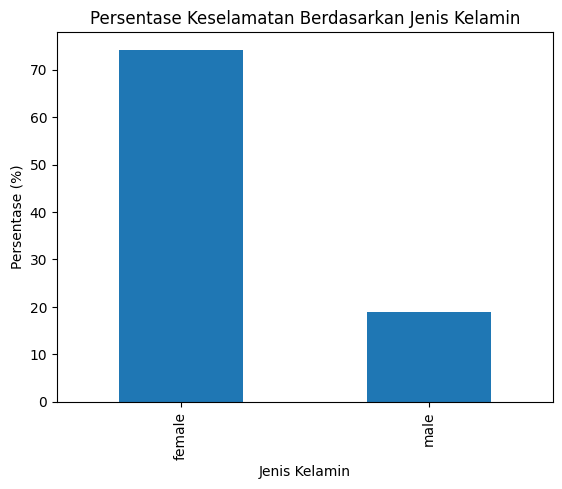

In [9]:
import matplotlib.pyplot as plt

survival_gender.plot(kind='bar')

plt.title('Persentase Keselamatan Berdasarkan Jenis Kelamin')
plt.ylabel('Persentase (%)')
plt.xlabel('Jenis Kelamin')
plt.show()

Tingkat keselamatan penumpang wanita lebih tinggi dibandingkan penumpang pria.
Hal ini sesuai dengan kebijakan evakuasi Titanic yang mengutamakan wanita dan anak-anak terlebih dahulu.

# Kesimpulan

1. Dataset Titanic terdiri dari data penumpang beserta informasi keselamatan mereka.
2. Terdapat beberapa kolom yang memiliki missing values seperti Age, Cabin, dan Embarked.
3. Persentase penumpang yang selamat sekitar 38%.
4. Penumpang wanita kelas 1 memiliki karakteristik khusus dengan rata-rata usia tertentu.
5. Tingkat keselamatan tertinggi ditemukan pada kelas 1.
6. Jenis kelamin memiliki pengaruh signifikan terhadap peluang keselamatan, di mana wanita memiliki tingkat keselamatan lebih tinggi dibandingkan pria.